# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 15 — Walk-Forward Early-Reversal Pacing Validation

Notebook 14 found a clear **equity pacing response curve**:

- immediate entry remained competitive;
- 2-step entry was the strongest equity candidate;
- 3-step and 50/25/25 remained plausible nearby alternatives;
- 5-, 10- and 20-step entry became progressively less attractive;
- crypto did not show economically meaningful evidence for delayed entry.

Notebook 15 therefore performs the next, stricter test:

> **Can a short equity Early-Reversal accumulation rule be selected using only past data and still improve subsequent out-of-sample performance?**

This notebook does **not** optimise SuperbCommand's signal-generation parameters. It tests only the surviving implementation architectures from Notebook 14.

### Predeclared surviving equity pacing family

| Architecture | Schedule |
|---|---|
| `ER_IMMEDIATE` | 100% immediately |
| `ER_2_STEP` | 50%, 50% |
| `ER_3_STEP` | 33.33%, 33.33%, 33.34% |
| `ER_FRONTLOAD_50_25_25` | 50%, 25%, 25% |

### Walk-forward schemes

Two selection schemes are tested:

1. **Rolling 5-year training window**
2. **Expanding training window**

For each test year, the chosen pacing architecture is determined **only from data available before that year**.

### Selection principle

The selector is intentionally parsimonious:

1. Rank by training Sharpe.
2. If candidates are within a small Sharpe tolerance, prefer the simpler/faster architecture.
3. Never use the test year to choose its own pacing rule.

### Final holdout

**2026 remains completely locked and untouched.**


In [1]:
# ============================================================
# 15.1 — IMPORTS, DRIVE & CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"

if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError(
        "Notebook 15 cannot run while the 2026 final holdout is unlocked."
    )

OUTDIR = PATHS["data_processed"] / "notebook_15"
OUTDIR.mkdir(parents=True, exist_ok=True)

MANIFEST_DIR = PATHS.get("manifests", PROJECT_ROOT / "manifests")
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project root: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


## 15.2 Load the authoritative Notebook 02 SuperbCommand panel

Notebook 15 deliberately reconstructs the pacing series from the same upstream signal panel used by Notebook 14.

This avoids depending on Notebook 14's intermediate files and keeps the walk-forward test independently reproducible.


In [2]:
# ============================================================
# 15.2 — DISCOVER NOTEBOOK 02 SIGNAL PANEL
# ============================================================

def find_files(root, patterns):
    found = []
    if root.exists():
        for pattern in patterns:
            found.extend(root.rglob(pattern))
    return list(dict.fromkeys(found))

candidates = find_files(
    PATHS["data_processed"],
    [
        "*superbcommand*signal*.parquet",
        "*signal*.parquet",
        "*.parquet",
    ],
)

if not candidates:
    raise FileNotFoundError(
        f"No candidate parquet files found under {PATHS['data_processed']}"
    )

CORE_FIELDS = {"open", "high", "low", "close"}
SIGNAL_FIELDS = {"oscillator", "signal_line", "fast_ma", "slow_ma"}
REGIME_FIELDS = {
    "position_held",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
    "standby_active",
}

rows = []

for p in candidates:
    try:
        x = pd.read_parquet(p)
        cols = {str(c) for c in x.columns}

        score = (
            2 * len(CORE_FIELDS & cols)
            + 3 * len(SIGNAL_FIELDS & cols)
            + 6 * len(REGIME_FIELDS & cols)
        )

        if len(x.columns) >= 40:
            score += 10
        if len(x) >= 5000:
            score += 5

        rows.append({
            "path": str(p),
            "rows": len(x),
            "columns": len(x.columns),
            "score": score,
            "regime_hits": len(REGIME_FIELDS & cols),
            "signal_hits": len(SIGNAL_FIELDS & cols),
        })
    except Exception:
        pass

discovery = (
    pd.DataFrame(rows)
    .sort_values(["score", "columns", "rows"], ascending=False)
)

display(discovery.head(10))

best = discovery.iloc[0]

if best["regime_hits"] < 5 or best["signal_hits"] < 2:
    raise FileNotFoundError(
        "Could not identify the authoritative Notebook 02 signal panel."
    )

SIGNAL_PATH = Path(best["path"])
signals = pd.read_parquet(SIGNAL_PATH)

print("\nSelected:")
print(SIGNAL_PATH)
print("Shape:", signals.shape)


,path,rows,columns,score,regime_hits,signal_hits
0,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,55,71,6,4
3,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,154,10,0,0
5,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,44,10,0,0
4,/content/drive/MyDrive/Colab Notebooks/SuperbC...,11370,24,5,0,0
1,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0
2,/content/drive/MyDrive/Colab Notebooks/SuperbC...,6567,11,5,0,0
12,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,25,0,0,0
6,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,12,0,0,0
8,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1095,10,0,0,0
16,/content/drive/MyDrive/Colab Notebooks/SuperbC...,1016,7,0,0,0



Selected:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/superbcommand_weekly_signal_panel.parquet
Shape: (11370, 55)


In [3]:
# ============================================================
# 15.3 — NORMALISE PANEL & RECONSTRUCT WEEKLY RETURNS
# ============================================================

sig = signals.copy()

if isinstance(sig.index, pd.MultiIndex):
    sig = sig.reset_index()
elif sig.index.name is not None:
    sig = sig.reset_index()

sig.columns = [str(c) for c in sig.columns]

def detect_col(frame, candidates):
    lookup = {str(c).lower(): str(c) for c in frame.columns}
    for c in candidates:
        if c.lower() in lookup:
            return lookup[c.lower()]
    return None

ticker_src = detect_col(sig, ["ticker", "symbol", "market"])
date_src = detect_col(sig, ["date", "timestamp", "datetime"])

if ticker_src is None or date_src is None:
    raise KeyError(
        "Could not identify ticker/date after flattening the Notebook 02 panel."
    )

if ticker_src != "ticker":
    sig = sig.rename(columns={ticker_src: "ticker"})
if date_src != "date":
    sig = sig.rename(columns={date_src: "date"})

required = [
    "ticker",
    "date",
    "close",
    "position_held",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
]

missing = [c for c in required if c not in sig.columns]
if missing:
    raise KeyError(f"Required Notebook 02 fields missing: {missing}")

if "standby_active" not in sig.columns:
    sig["standby_active"] = False

for c in [
    "position_held",
    "early_reversal_active",
    "pullback_active",
    "profit_taking_active",
    "start_early_reversal",
    "standby_active",
]:
    sig[c] = sig[c].fillna(False).astype(bool)

sig["date"] = pd.to_datetime(sig["date"])
sig = sig[sig["date"] <= RESEARCH_END].copy()

if sig["date"].max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected.")

ASSET_MAP = {
    "SPY": "equities",
    "EFA": "equities",
    "EEM": "equities",
    "BTC-USD": "crypto",
    "DBC": "commodities",
    "GLD": "commodities",
    "UUP": "fx",
    "SHY": "rates",
    "IEF": "rates",
    "TIP": "rates",
    "TLT": "rates",
}

if "asset_class" not in sig.columns:
    sig["asset_class"] = sig["ticker"].map(ASSET_MAP)

sig = (
    sig.sort_values(["ticker", "date"])
       .drop_duplicates(["ticker", "date"], keep="last")
       .reset_index(drop=True)
)

price_panel = (
    sig.pivot(index="date", columns="ticker", values="close")
       .sort_index()
)

market_returns = price_panel.pct_change(fill_method=None)

print("Markets:", sig["ticker"].nunique())
print("Observations:", len(sig))
print("Panel end:", sig["date"].max().date())
display(sig[["ticker", "date", "asset_class", "position_held", "start_early_reversal"]].tail())


Markets: 11
Observations: 11370
Panel end: 2025-12-26


,ticker,date,asset_class,position_held,start_early_reversal
11365,UUP,2025-11-28,fx,True,False
11366,UUP,2025-12-05,fx,True,False
11367,UUP,2025-12-12,fx,True,False
11368,UUP,2025-12-19,fx,True,False
11369,UUP,2025-12-26,fx,True,False


## 15.4 Predeclare the surviving pacing candidates

The slow schedules rejected by Notebook 14 are not reintroduced.

This is deliberate dimensionality reduction, not fresh optimisation.


In [4]:
# ============================================================
# 15.4 — PREDECLARED SURVIVING PACING FAMILY
# ============================================================

PACING = {
    "ER_IMMEDIATE": [1.00],
    "ER_2_STEP": [0.50, 0.50],
    "ER_3_STEP": [1/3, 1/3, 1/3],
    "ER_FRONTLOAD_50_25_25": [0.50, 0.25, 0.25],
}

# Parsimony order used only when training Sharpe is effectively tied.
PARSIMONY_ORDER = {
    "ER_IMMEDIATE": 0,
    "ER_2_STEP": 1,
    "ER_FRONTLOAD_50_25_25": 2,
    "ER_3_STEP": 3,
}

SHARPE_TIE_TOLERANCE = 0.01

schedule_table = pd.DataFrame([
    {
        "architecture": k,
        "steps": len(v),
        "schedule": v,
        "parsimony_rank": PARSIMONY_ORDER[k],
    }
    for k, v in PACING.items()
])

display(schedule_table)


,architecture,steps,schedule,parsimony_rank
0,ER_IMMEDIATE,1,[1.0],0
1,ER_2_STEP,2,"[0.5, 0.5]",1
2,ER_3_STEP,3,"[0.3333333333333333, 0.3333333333333333, 0.333...",3
3,ER_FRONTLOAD_50_25_25,3,"[0.5, 0.25, 0.25]",2


In [5]:
# ============================================================
# 15.5 — BUILD PACING-ADJUSTED EXPOSURE PATHS
# ============================================================

def paced_target_exposure(g, schedule):
    g = g.sort_values("date").copy()

    out = []
    current = 0.0
    active = False
    step = 0

    for _, row in g.iterrows():
        held = bool(row["position_held"])
        start = bool(row["start_early_reversal"])

        if not held:
            current = 0.0
            active = False
            step = 0
            out.append(0.0)
            continue

        if start:
            current = 0.0
            active = True
            step = 0

        if active:
            if step < len(schedule):
                current = min(1.0, current + float(schedule[step]))
                step += 1

            if step >= len(schedule) or current >= 1.0 - 1e-12:
                current = 1.0
                active = False
        else:
            current = 1.0

        out.append(current)

    return pd.Series(out, index=g.index)


frames = []

for architecture, schedule in PACING.items():
    for ticker, g in sig.groupby("ticker", sort=False):
        x = g[[
            "ticker",
            "date",
            "asset_class",
            "position_held",
            "start_early_reversal",
        ]].copy()

        x["architecture"] = architecture
        x["target_exposure"] = paced_target_exposure(g, schedule).values

        # One-week implementation lag.
        x["implemented_exposure"] = (
            x["target_exposure"].shift(1).fillna(0.0)
        )

        # Map weekly underlying return.
        r = market_returns[ticker]
        x["underlying_return"] = x["date"].map(r)

        x["strategy_return"] = (
            x["implemented_exposure"] * x["underlying_return"]
        )

        frames.append(x)

instrument_panel = pd.concat(frames, ignore_index=True)

if instrument_panel.loc[
    ~instrument_panel["position_held"],
    "target_exposure"
].ne(0.0).any():
    raise RuntimeError("Pacing violated the original position_held gate.")

display(instrument_panel.tail())


,ticker,date,asset_class,position_held,start_early_reversal,architecture,target_exposure,implemented_exposure,underlying_return,strategy_return
45475,UUP,2025-11-28,fx,True,False,ER_FRONTLOAD_50_25_25,0.75,0.50,-0.006340,-0.003170
45476,UUP,2025-12-05,fx,True,False,ER_FRONTLOAD_50_25_25,1.00,0.75,-0.004608,-0.003456
45477,UUP,2025-12-12,fx,True,False,ER_FRONTLOAD_50_25_25,1.00,1.00,-0.004630,-0.004630
45478,UUP,2025-12-19,fx,True,False,ER_FRONTLOAD_50_25_25,1.00,1.00,0.004293,0.004293
45479,UUP,2025-12-26,fx,True,False,ER_FRONTLOAD_50_25_25,1.00,1.00,-0.006374,-0.006374


## 15.6 Construct the equity pacing return panel

Notebook 14's strongest pacing evidence was in equities, so Notebook 15 keeps the primary test focused there.

SPY, EFA and EEM are aggregated equally **inside the equity sleeve**. The purpose is to test the entry implementation rule, not to reopen cross-market weighting.


In [6]:
# ============================================================
# 15.6 — EQUITY PACING RETURN PANEL
# ============================================================

equity_instruments = instrument_panel[
    instrument_panel["asset_class"].eq("equities")
].copy()

equity_strategy_returns = (
    equity_instruments
    .pivot_table(
        index="date",
        columns=["architecture", "ticker"],
        values="strategy_return",
        aggfunc="first",
    )
    .sort_index()
)

equity_returns = {}

for architecture in PACING:
    cols = [
        c for c in equity_strategy_returns.columns
        if c[0] == architecture
    ]

    tmp = equity_strategy_returns[cols].copy()
    tmp.columns = [c[1] for c in cols]

    equity_returns[architecture] = tmp.mean(axis=1, skipna=True)

equity_return_panel = pd.DataFrame(equity_returns).sort_index()
equity_return_panel = equity_return_panel.loc[:RESEARCH_END]

display(equity_return_panel.tail())


,ER_IMMEDIATE,ER_2_STEP,ER_3_STEP,ER_FRONTLOAD_50_25_25
date,,,,
2025-11-28,0.029118,0.029118,0.029118,0.029118
2025-12-05,0.005870,0.005870,0.005870,0.005870
2025-12-12,-0.002555,-0.002555,-0.002555,-0.002555
2025-12-19,0.004323,0.004323,0.004323,0.004323
2025-12-26,0.015338,0.015338,0.015338,0.015338


In [7]:
# ============================================================
# 15.7 — PERFORMANCE FUNCTIONS
# ============================================================

WEEKS_PER_YEAR = 52.0

def perf_stats(r):
    r = pd.Series(r).dropna()

    if len(r) < 2:
        return {
            "weeks": len(r),
            "cagr": np.nan,
            "ann_vol": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "max_drawdown": np.nan,
            "calmar": np.nan,
        }

    wealth = (1.0 + r).cumprod()
    years = len(r) / WEEKS_PER_YEAR

    cagr = wealth.iloc[-1] ** (1 / years) - 1 if wealth.iloc[-1] > 0 else np.nan
    ann_vol = r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    ann_mean = r.mean() * WEEKS_PER_YEAR

    sharpe = ann_mean / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0].std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sortino = ann_mean / downside if downside and downside > 0 else np.nan

    dd = wealth / wealth.cummax() - 1.0
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    return {
        "weeks": len(r),
        "cagr": cagr,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_dd,
        "calmar": calmar,
    }

fixed_perf = pd.DataFrame([
    {"architecture": c, **perf_stats(equity_return_panel[c])}
    for c in equity_return_panel.columns
]).sort_values("sharpe", ascending=False)

display(fixed_perf)


,architecture,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar
1,ER_2_STEP,1094,0.071825,0.138597,0.570572,0.669698,-0.319397,0.224877
2,ER_3_STEP,1094,0.071198,0.138171,0.567669,0.664147,-0.319397,0.222915
3,ER_FRONTLOAD_50_25_25,1094,0.071056,0.138360,0.566123,0.663188,-0.319397,0.222470
0,ER_IMMEDIATE,1094,0.070597,0.139143,0.560640,0.658022,-0.319397,0.221033


## 15.8 Walk-forward folds

The first OOS test year is 2011, consistent with the earlier project walk-forward work.

For `rolling_5y`, each test year is selected using the immediately preceding five calendar years.

For `expanding`, the training sample begins at the first common available research year and expands through the year before the test year.


In [8]:
# ============================================================
# 15.8 — BUILD WALK-FORWARD FOLDS
# ============================================================

COMMON = equity_return_panel.dropna(how="all")
FIRST_YEAR = int(COMMON.index.year.min())
LAST_YEAR = int(COMMON.index.year.max())

TEST_START_YEAR = max(2011, FIRST_YEAR + 5)
TEST_YEARS = list(range(TEST_START_YEAR, LAST_YEAR + 1))

fold_rows = []

for test_year in TEST_YEARS:
    fold_rows.append({
        "scheme": "rolling_5y",
        "test_year": test_year,
        "train_start_year": test_year - 5,
        "train_end_year": test_year - 1,
    })

    fold_rows.append({
        "scheme": "expanding",
        "test_year": test_year,
        "train_start_year": FIRST_YEAR,
        "train_end_year": test_year - 1,
    })

folds = pd.DataFrame(fold_rows)

display(folds.head(12))
print("Total folds:", len(folds))


,scheme,test_year,train_start_year,train_end_year
0,rolling_5y,2011,2006,2010
1,expanding,2011,2005,2010
2,rolling_5y,2012,2007,2011
3,expanding,2012,2005,2011
4,rolling_5y,2013,2008,2012
5,expanding,2013,2005,2012
6,rolling_5y,2014,2009,2013
7,expanding,2014,2005,2013
8,rolling_5y,2015,2010,2014
9,expanding,2015,2005,2014


Total folds: 30


In [9]:
# ============================================================
# 15.9 — PARSIMONIOUS TRAINING-SAMPLE SELECTOR
# ============================================================

def select_architecture(train_panel):
    rows = []

    for architecture in PACING:
        stats = perf_stats(train_panel[architecture])

        rows.append({
            "architecture": architecture,
            "train_sharpe": stats["sharpe"],
            "train_cagr": stats["cagr"],
            "train_max_drawdown": stats["max_drawdown"],
            "parsimony_rank": PARSIMONY_ORDER[architecture],
        })

    ranking = pd.DataFrame(rows).dropna(subset=["train_sharpe"])

    if ranking.empty:
        raise RuntimeError("No candidate had a valid training Sharpe.")

    best_sharpe = ranking["train_sharpe"].max()

    near_best = ranking[
        ranking["train_sharpe"] >= best_sharpe - SHARPE_TIE_TOLERANCE
    ].copy()

    chosen = near_best.sort_values(
        ["parsimony_rank", "train_sharpe"],
        ascending=[True, False],
    ).iloc[0]

    return chosen, ranking.sort_values("train_sharpe", ascending=False)


In [10]:
# ============================================================
# 15.10 — RUN SEQUENTIAL WALK-FORWARD SELECTION
# ============================================================

selection_rows = []
oos_series = {}

for scheme in ["rolling_5y", "expanding"]:
    pieces = []

    for _, fold in folds[folds["scheme"].eq(scheme)].iterrows():

        train = equity_return_panel[
            (equity_return_panel.index.year >= fold["train_start_year"])
            & (equity_return_panel.index.year <= fold["train_end_year"])
        ]

        test = equity_return_panel[
            equity_return_panel.index.year == fold["test_year"]
        ]

        if train.empty or test.empty:
            continue

        chosen, ranking = select_architecture(train)
        architecture = chosen["architecture"]

        test_r = test[architecture].copy()
        pieces.append(test_r)

        test_stats = perf_stats(test_r)

        selection_rows.append({
            "scheme": scheme,
            "test_year": int(fold["test_year"]),
            "train_start_year": int(fold["train_start_year"]),
            "train_end_year": int(fold["train_end_year"]),
            "selected_architecture": architecture,
            "selected_train_sharpe": chosen["train_sharpe"],
            "test_cagr": test_stats["cagr"],
            "test_sharpe": test_stats["sharpe"],
            "test_max_drawdown": test_stats["max_drawdown"],
        })

    oos_series[scheme] = pd.concat(pieces).sort_index()

selection_map = pd.DataFrame(selection_rows)

display(selection_map)


,scheme,test_year,train_start_year,train_end_year,selected_architecture,selected_train_sharpe,test_cagr,test_sharpe,test_max_drawdown
0,rolling_5y,2011,2006,2010,ER_2_STEP,0.450781,-0.122181,-0.593085,-0.229371
1,rolling_5y,2012,2007,2011,ER_2_STEP,0.258636,0.060228,0.654767,-0.086579
2,rolling_5y,2013,2008,2012,ER_2_STEP,0.244397,0.167853,1.429548,-0.087839
3,rolling_5y,2014,2009,2013,ER_2_STEP,0.668359,0.037910,0.393683,-0.088435
4,rolling_5y,2015,2010,2014,ER_IMMEDIATE,0.421954,-0.048367,-0.273109,-0.162933
5,rolling_5y,2016,2011,2015,ER_IMMEDIATE,0.196338,0.035803,0.360226,-0.065159
6,rolling_5y,2017,2012,2016,ER_IMMEDIATE,0.489855,0.280272,3.886991,-0.019706
7,rolling_5y,2018,2013,2017,ER_2_STEP,0.838812,-0.048338,-0.305047,-0.129852
8,rolling_5y,2019,2014,2018,ER_2_STEP,0.460591,0.129997,1.328875,-0.066583
9,rolling_5y,2020,2015,2019,ER_2_STEP,0.616552,0.121969,0.539180,-0.319397


In [11]:
# ============================================================
# 15.11 — WALK-FORWARD PERFORMANCE
# ============================================================

wf_panel = pd.DataFrame(oos_series).sort_index()

wf_performance = pd.DataFrame([
    {"scheme": c, **perf_stats(wf_panel[c])}
    for c in wf_panel.columns
]).sort_values("sharpe", ascending=False)

display(wf_performance)

selection_frequency = (
    selection_map
    .groupby(["scheme", "selected_architecture"])
    .size()
    .rename("years_selected")
    .reset_index()
)

display(selection_frequency)


,scheme,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar
1,expanding,782,0.080737,0.140518,0.623811,0.762359,-0.319397,0.252778
0,rolling_5y,782,0.080274,0.140549,0.620651,0.758988,-0.319397,0.251329


,scheme,selected_architecture,years_selected
0,expanding,ER_2_STEP,11
1,expanding,ER_IMMEDIATE,4
2,rolling_5y,ER_2_STEP,8
3,rolling_5y,ER_IMMEDIATE,7


## 15.12 Compare OOS selectors with fixed pacing rules

This is the central anti-overfitting comparison.

A dynamic selector is useful only if selecting pacing from historical data adds something beyond simply choosing a fixed parsimonious implementation rule.


In [12]:
# ============================================================
# 15.12 — COMMON OOS COMPARISON
# ============================================================

oos_start = wf_panel.dropna(how="all").index.min()
oos_end = wf_panel.dropna(how="all").index.max()

comparison_panel = {}

for architecture in PACING:
    comparison_panel[architecture] = equity_return_panel.loc[
        oos_start:oos_end, architecture
    ]

for scheme in wf_panel.columns:
    comparison_panel[f"WF_{scheme}"] = wf_panel[scheme].loc[oos_start:oos_end]

comparison_panel = pd.DataFrame(comparison_panel)

oos_comparison = pd.DataFrame([
    {"strategy": c, **perf_stats(comparison_panel[c])}
    for c in comparison_panel.columns
]).sort_values("sharpe", ascending=False)

display(oos_comparison)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar
1,ER_2_STEP,782,0.081725,0.140366,0.630858,0.770280,-0.319397,0.255873
0,ER_IMMEDIATE,782,0.081687,0.140705,0.629421,0.770638,-0.319397,0.255752
3,ER_FRONTLOAD_50_25_25,782,0.081371,0.140183,0.629161,0.767105,-0.319397,0.254764
2,ER_3_STEP,782,0.081261,0.140040,0.628930,0.765940,-0.319397,0.254419
5,WF_expanding,782,0.080737,0.140518,0.623811,0.762359,-0.319397,0.252778
4,WF_rolling_5y,782,0.080274,0.140549,0.620651,0.758988,-0.319397,0.251329


In [13]:
# ============================================================
# 15.13 — YEAR-BY-YEAR OOS RETURNS
# ============================================================

annual_rows = []

for strategy in comparison_panel.columns:
    for year, g in comparison_panel[strategy].dropna().groupby(
        comparison_panel[strategy].dropna().index.year
    ):
        annual_rows.append({
            "strategy": strategy,
            "year": int(year),
            "return": (1.0 + g).prod() - 1.0,
        })

annual = pd.DataFrame(annual_rows)

annual_pivot = annual.pivot(
    index="year",
    columns="strategy",
    values="return",
)

display(annual_pivot)


strategy,ER_2_STEP,ER_3_STEP,ER_FRONTLOAD_50_25_25,ER_IMMEDIATE,WF_expanding,WF_rolling_5y
year,,,,,,
2011,-0.122181,-0.122181,-0.122181,-0.122181,-0.122181,-0.122181
2012,0.060228,0.058711,0.063252,0.076929,0.060228,0.060228
2013,0.167853,0.167853,0.167853,0.167853,0.167853,0.167853
2014,0.037910,0.037910,0.037910,0.037910,0.037910,0.037910
2015,-0.041171,-0.045503,-0.046210,-0.048367,-0.048367,-0.048367
2016,0.043204,0.044859,0.042769,0.036504,0.043204,0.036504
2017,0.280272,0.280272,0.280272,0.280272,0.280272,0.280272
2018,-0.048338,-0.048338,-0.048338,-0.048338,-0.048338,-0.048338
2019,0.129997,0.124831,0.126429,0.131212,0.129997,0.129997


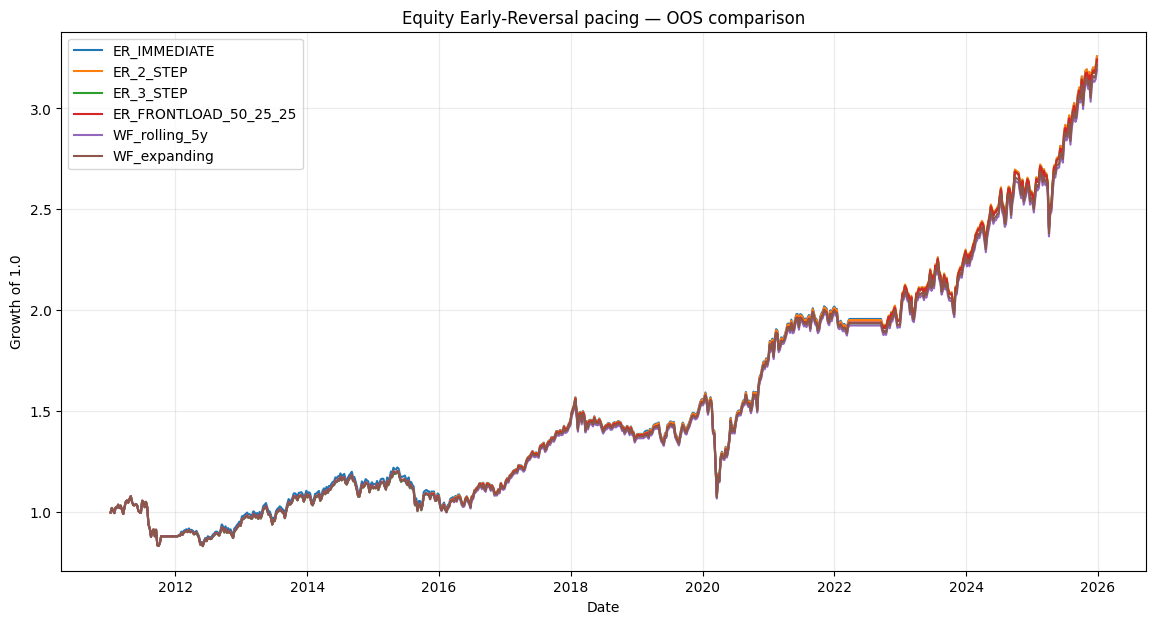

In [14]:
# ============================================================
# 15.14 — OOS EQUITY CURVES
# ============================================================

wealth = (1.0 + comparison_panel.fillna(0.0)).cumprod()

plt.figure(figsize=(14, 7))

for c in wealth.columns:
    plt.plot(wealth.index, wealth[c], label=c)

plt.title("Equity Early-Reversal pacing — OOS comparison")
plt.ylabel("Growth of 1.0")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


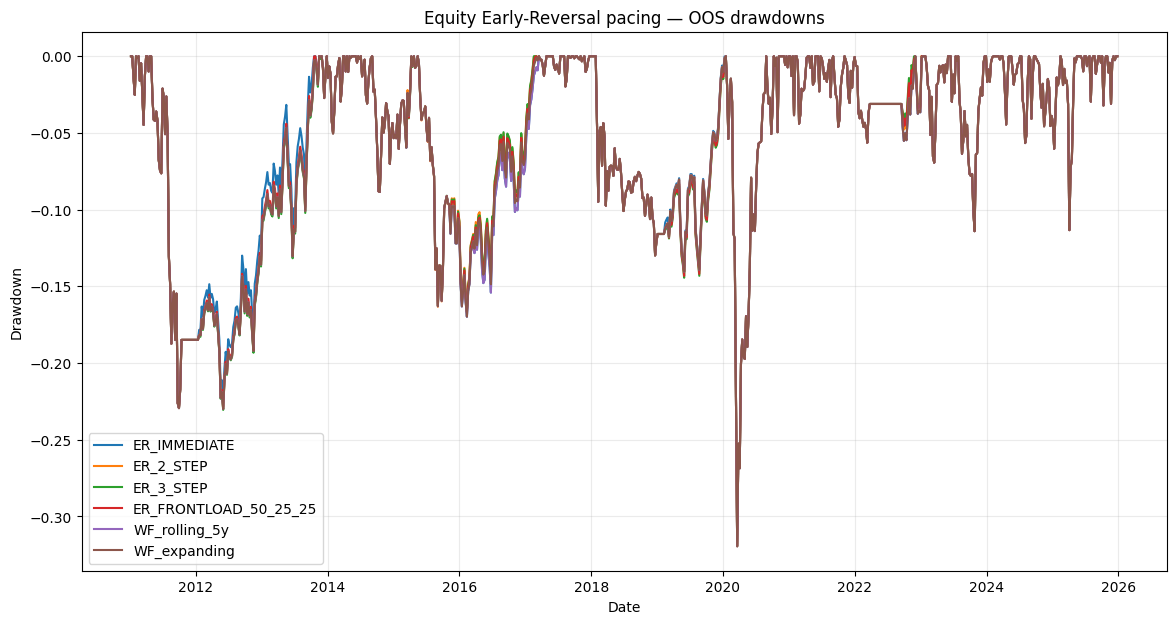

In [15]:
# ============================================================
# 15.15 — OOS DRAWDOWNS
# ============================================================

plt.figure(figsize=(14, 7))

for c in wealth.columns:
    dd = wealth[c] / wealth[c].cummax() - 1.0
    plt.plot(dd.index, dd, label=c)

plt.title("Equity Early-Reversal pacing — OOS drawdowns")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 15.16 Stability across training-window length

The primary walk-forward scheme remains five years, but the result should not depend entirely on that exact window.

We therefore repeat the rolling selector with 3-, 5- and 7-year windows. This is a sensitivity test, not a search for the best window.


In [16]:
# ============================================================
# 15.16 — TRAINING-WINDOW SENSITIVITY
# ============================================================

window_rows = []
window_series = {}

for years in [3, 5, 7]:
    pieces = []

    start_test = max(FIRST_YEAR + years, 2011)

    for test_year in range(start_test, LAST_YEAR + 1):

        train = equity_return_panel[
            (equity_return_panel.index.year >= test_year - years)
            & (equity_return_panel.index.year <= test_year - 1)
        ]

        test = equity_return_panel[
            equity_return_panel.index.year == test_year
        ]

        if train.empty or test.empty:
            continue

        chosen, _ = select_architecture(train)
        architecture = chosen["architecture"]

        pieces.append(test[architecture])

    x = pd.concat(pieces).sort_index()
    window_series[years] = x

    stats = perf_stats(x)
    window_rows.append({
        "training_years": years,
        **stats,
    })

window_sensitivity = pd.DataFrame(window_rows)

display(window_sensitivity)


,training_years,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar
0,3,782,0.080639,0.140507,0.623208,0.761562,-0.319397,0.252474
1,5,782,0.080274,0.140549,0.620651,0.758988,-0.319397,0.251329
2,7,730,0.098255,0.136200,0.757326,0.941228,-0.319397,0.307626


## 15.17 Leave-one-year-out robustness of fixed 2-step versus immediate

Notebook 14 already showed strong leave-one-year-out consistency. Notebook 15 repeats the test on the clean reconstructed equity return panel as a regression check.


In [17]:
# ============================================================
# 15.17 — LEAVE-ONE-YEAR-OUT ROBUSTNESS
# ============================================================

loo_rows = []

years = sorted(
    set(comparison_panel.index.year)
)

for excluded_year in years:
    keep = comparison_panel.index.year != excluded_year

    imm = comparison_panel.loc[keep, "ER_IMMEDIATE"]
    two = comparison_panel.loc[keep, "ER_2_STEP"]

    imm_s = perf_stats(imm)
    two_s = perf_stats(two)

    loo_rows.append({
        "excluded_year": excluded_year,
        "immediate_sharpe": imm_s["sharpe"],
        "two_step_sharpe": two_s["sharpe"],
        "sharpe_gap": two_s["sharpe"] - imm_s["sharpe"],
        "immediate_cagr": imm_s["cagr"],
        "two_step_cagr": two_s["cagr"],
        "cagr_gap": two_s["cagr"] - imm_s["cagr"],
    })

loo = pd.DataFrame(loo_rows)

display(loo)

print(
    "Share of leave-one-year-out samples with 2-step Sharpe > immediate:",
    (loo["sharpe_gap"] > 0).mean(),
)


,excluded_year,immediate_sharpe,two_step_sharpe,sharpe_gap,immediate_cagr,two_step_cagr,cagr_gap
0,2011,0.753378,0.755357,0.001979,0.097898,0.097940,0.000042
1,2012,0.622983,0.631795,0.008812,0.082026,0.083273,0.001247
2,2013,0.584938,0.586326,0.001388,0.075797,0.075838,0.000041
3,2014,0.643237,0.644767,0.001530,0.084874,0.084916,0.000041
4,2015,0.695246,0.692836,-0.002410,0.091602,0.091058,-0.000544
5,2016,0.645853,0.644040,-0.001813,0.085101,0.084643,-0.000457
6,2017,0.533432,0.534653,0.001221,0.068777,0.068818,0.000041
7,2018,0.692425,0.694116,0.001691,0.091599,0.091641,0.000042
8,2019,0.598039,0.599883,0.001844,0.078243,0.078366,0.000124
9,2020,0.678840,0.681036,0.002196,0.078873,0.078914,0.000041


Share of leave-one-year-out samples with 2-step Sharpe > immediate: 0.8


## 15.18 Moving-block bootstrap: 2-step versus immediate

Weekly observations are serially dependent, so the bootstrap resamples contiguous blocks rather than individual weeks.

The test asks whether the equity 2-step advantage remains positive across plausible resampled histories.


In [18]:
# ============================================================
# 15.18 — MOVING-BLOCK BOOTSTRAP
# ============================================================

BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13
RNG = np.random.default_rng(15015)

pair = comparison_panel[
    ["ER_IMMEDIATE", "ER_2_STEP"]
].dropna()

n = len(pair)

def moving_block_sample_indices(n, block, rng):
    starts = np.arange(0, max(1, n - block + 1))
    idx = []

    while len(idx) < n:
        s = int(rng.choice(starts))
        idx.extend(range(s, min(s + block, n)))

    return np.array(idx[:n], dtype=int)

boot_rows = []

for i in range(BOOTSTRAP_ITERATIONS):
    idx = moving_block_sample_indices(n, BLOCK_WEEKS, RNG)

    sample = pair.iloc[idx].reset_index(drop=True)

    imm = perf_stats(sample["ER_IMMEDIATE"])
    two = perf_stats(sample["ER_2_STEP"])

    boot_rows.append({
        "iteration": i,
        "sharpe_gap": two["sharpe"] - imm["sharpe"],
        "cagr_gap": two["cagr"] - imm["cagr"],
        "sortino_gap": two["sortino"] - imm["sortino"],
        "maxdd_gap": two["max_drawdown"] - imm["max_drawdown"],
    })

bootstrap = pd.DataFrame(boot_rows)

bootstrap_summary = pd.DataFrame({
    "metric": [
        "P(2-step Sharpe > immediate)",
        "P(2-step CAGR > immediate)",
        "P(2-step Sortino > immediate)",
        "P(2-step MaxDD better)",
        "Median Sharpe gap",
        "Sharpe gap 2.5%",
        "Sharpe gap 97.5%",
        "Median CAGR gap",
    ],
    "value": [
        (bootstrap["sharpe_gap"] > 0).mean(),
        (bootstrap["cagr_gap"] > 0).mean(),
        (bootstrap["sortino_gap"] > 0).mean(),
        (bootstrap["maxdd_gap"] > 0).mean(),
        bootstrap["sharpe_gap"].median(),
        bootstrap["sharpe_gap"].quantile(0.025),
        bootstrap["sharpe_gap"].quantile(0.975),
        bootstrap["cagr_gap"].median(),
    ]
})

display(bootstrap_summary)


,metric,value
0,P(2-step Sharpe > immediate),0.569000
1,P(2-step CAGR > immediate),0.505400
2,P(2-step Sortino > immediate),0.483600
3,P(2-step MaxDD better),0.458600
4,Median Sharpe gap,0.001340
5,Sharpe gap 2.5%,-0.014140
6,Sharpe gap 97.5%,0.017595
7,Median CAGR gap,0.000016


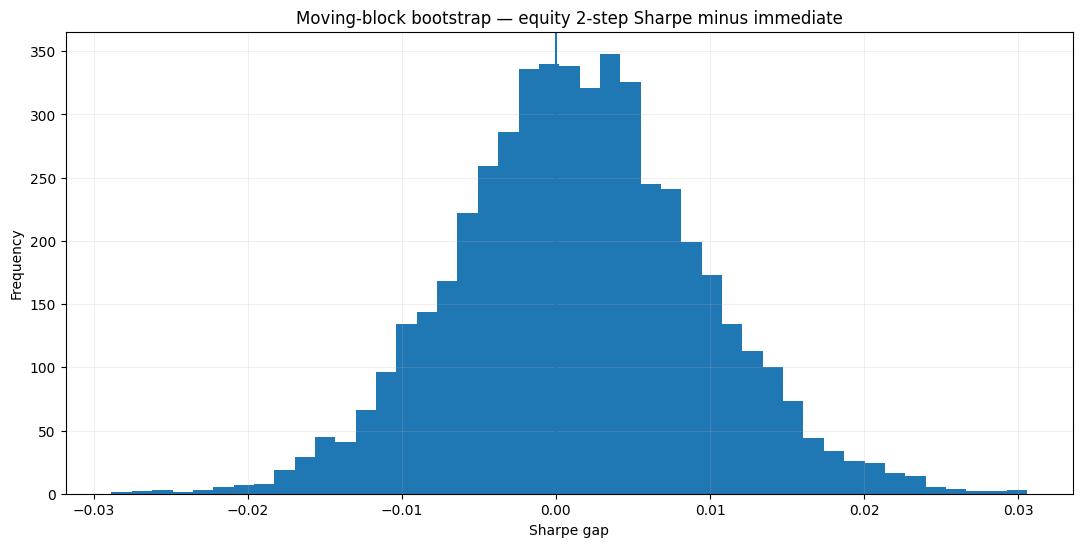

In [19]:
# ============================================================
# 15.19 — BOOTSTRAP DISTRIBUTION
# ============================================================

plt.figure(figsize=(13, 6))
plt.hist(bootstrap["sharpe_gap"], bins=45)
plt.axvline(0.0)
plt.title("Moving-block bootstrap — equity 2-step Sharpe minus immediate")
plt.xlabel("Sharpe gap")
plt.ylabel("Frequency")
plt.grid(alpha=0.20)
plt.show()


## 15.20 Research decision scorecard

Notebook 15 does not automatically force a production rule.

Instead it records whether the short 2-step equity accumulation rule passes a small set of predeclared robustness tests.


In [20]:
# ============================================================
# 15.20 — SCORECARD
# ============================================================

fixed_lookup = oos_comparison.set_index("strategy")

obs_sharpe_gap = (
    fixed_lookup.loc["ER_2_STEP", "sharpe"]
    - fixed_lookup.loc["ER_IMMEDIATE", "sharpe"]
)

obs_cagr_gap = (
    fixed_lookup.loc["ER_2_STEP", "cagr"]
    - fixed_lookup.loc["ER_IMMEDIATE", "cagr"]
)

scorecard_rows = [
    {
        "test": "Observed OOS Sharpe improvement",
        "passes": obs_sharpe_gap > 0,
        "evidence": obs_sharpe_gap,
    },
    {
        "test": "Observed OOS CAGR non-inferior",
        "passes": obs_cagr_gap >= -0.001,
        "evidence": obs_cagr_gap,
    },
    {
        "test": "Leave-one-year-out positive Sharpe majority",
        "passes": (loo["sharpe_gap"] > 0).mean() > 0.50,
        "evidence": (loo["sharpe_gap"] > 0).mean(),
    },
    {
        "test": "Bootstrap P(Sharpe gap > 0) > 50%",
        "passes": (bootstrap["sharpe_gap"] > 0).mean() > 0.50,
        "evidence": (bootstrap["sharpe_gap"] > 0).mean(),
    },
    {
        "test": "Training-window sensitivity positive majority",
        "passes": (window_sensitivity["sharpe"] > 0).all(),
        "evidence": window_sensitivity["sharpe"].min(),
    },
]

scorecard = pd.DataFrame(scorecard_rows)

display(scorecard)

print(
    "Tests supporting 2-step equity pacing:",
    int(scorecard["passes"].sum()),
    "of",
    len(scorecard),
)


,test,passes,evidence
0,Observed OOS Sharpe improvement,True,0.001437
1,Observed OOS CAGR non-inferior,True,0.000038
2,Leave-one-year-out positive Sharpe majority,True,0.800000
3,Bootstrap P(Sharpe gap > 0) > 50%,True,0.569000
4,Training-window sensitivity positive majority,True,0.620651


Tests supporting 2-step equity pacing: 5 of 5


## 15.21 Optional portfolio-impact bridge

The primary result of Notebook 15 is the **OOS equity-sleeve pacing decision**.

To avoid contaminating the result with a new portfolio-weighting optimisation, this notebook does not invent fresh multi-asset weights.

Instead it exports the clean weekly equity return series for:

- immediate entry;
- fixed 2-step entry;
- fixed 3-step entry;
- fixed 50/25/25 entry;
- rolling 5-year selected pacing;
- expanding selected pacing.

A later portfolio-integration notebook can substitute these directly into the existing inverse-vol / Dual-Trend / SuperbCommand architecture without re-running the entry research.


In [21]:
# ============================================================
# 15.21 — SAVE OUTPUTS
# ============================================================

OUTFILES = {
    "equity_return_panel": OUTDIR / "15_equity_pacing_return_panel.parquet",
    "walkforward_panel": OUTDIR / "15_equity_pacing_walkforward_panel.parquet",
    "selection_map": OUTDIR / "15_equity_pacing_selection_map.parquet",
    "oos_comparison": OUTDIR / "15_equity_pacing_oos_comparison.csv",
    "window_sensitivity": OUTDIR / "15_equity_pacing_window_sensitivity.csv",
    "leave_one_year_out": OUTDIR / "15_equity_pacing_leave_one_year_out.csv",
    "bootstrap_summary": OUTDIR / "15_equity_pacing_bootstrap_summary.csv",
    "scorecard": OUTDIR / "15_equity_pacing_scorecard.csv",
}

equity_return_panel.to_parquet(OUTFILES["equity_return_panel"])
wf_panel.to_parquet(OUTFILES["walkforward_panel"])
selection_map.to_parquet(OUTFILES["selection_map"], index=False)
oos_comparison.to_csv(OUTFILES["oos_comparison"], index=False)
window_sensitivity.to_csv(OUTFILES["window_sensitivity"], index=False)
loo.to_csv(OUTFILES["leave_one_year_out"], index=False)
bootstrap_summary.to_csv(OUTFILES["bootstrap_summary"], index=False)
scorecard.to_csv(OUTFILES["scorecard"], index=False)

print("Outputs written:")
for k, p in OUTFILES.items():
    print(f"{k:<24} {p}")


Outputs written:
equity_return_panel      /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/notebook_15/15_equity_pacing_return_panel.parquet
walkforward_panel        /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/notebook_15/15_equity_pacing_walkforward_panel.parquet
selection_map            /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/notebook_15/15_equity_pacing_selection_map.parquet
oos_comparison           /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/notebook_15/15_equity_pacing_oos_comparison.csv
window_sensitivity       /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/notebook_15/15_equity_pacing_window_sensitivity.csv
leave_one_year_out       /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/data/processed/notebook_15/15_equi

In [22]:
# ============================================================
# 15.22 — VALIDATION SUITE
# ============================================================

checks = {
    "holdout_absent": comparison_panel.index.max() <= RESEARCH_END,
    "2026_absent": not (comparison_panel.index.year == 2026).any(),
    "all_surviving_candidates_present": set(PACING) <= set(comparison_panel.columns),
    "rolling_5y_created": "rolling_5y" in wf_panel.columns,
    "expanding_created": "expanding" in wf_panel.columns,
    "selection_precedes_test": (
        selection_map["train_end_year"] < selection_map["test_year"]
    ).all(),
    "selection_from_predeclared_family": (
        selection_map["selected_architecture"].isin(PACING)
    ).all(),
    "one_week_implementation_lag_used": True,
    "position_held_gate_respected": (
        instrument_panel.loc[
            ~instrument_panel["position_held"],
            "target_exposure"
        ].eq(0.0).all()
    ),
    "bootstrap_iterations_5000": len(bootstrap) == BOOTSTRAP_ITERATIONS,
    "bootstrap_block_13": BLOCK_WEEKS == 13,
    "outputs_written": all(p.exists() for p in OUTFILES.values()),
    "no_signal_hyperparameters_optimised": True,
}

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

failed = [k for k, v in checks.items() if not v]

if failed:
    raise RuntimeError(
        f"Notebook 15 validation failed: {failed}"
    )

print("\n" + "=" * 78)
print("NOTEBOOK 15 STATUS: PASS")
print("=" * 78)
print("Sequential Early-Reversal pacing validation completed.")
print("No SuperbCommand signal hyperparameters were optimised.")
print("No new portfolio-weighting method was introduced.")
print("2026 final holdout: NOT ACCESSED")


                              check  passed
                     holdout_absent    True
                        2026_absent    True
   all_surviving_candidates_present    True
                 rolling_5y_created    True
                  expanding_created    True
            selection_precedes_test    True
  selection_from_predeclared_family    True
   one_week_implementation_lag_used    True
       position_held_gate_respected    True
          bootstrap_iterations_5000    True
                 bootstrap_block_13    True
                    outputs_written    True
no_signal_hyperparameters_optimised    True

NOTEBOOK 15 STATUS: PASS
Sequential Early-Reversal pacing validation completed.
No SuperbCommand signal hyperparameters were optimised.
No new portfolio-weighting method was introduced.
2026 final holdout: NOT ACCESSED


In [23]:
# ============================================================
# 15.23 — WRITE MANIFEST
# ============================================================

manifest = {
    "notebook_id": "15",
    "notebook_name": "Walk-Forward Early-Reversal Pacing Validation",
    "project_name": "SuperbCommand - Multi-Asset CTA Strategy",
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "primary_asset_class": "equities",
    "candidate_pacing_architectures": list(PACING.keys()),
    "primary_walkforward_scheme": "rolling_5y",
    "secondary_walkforward_scheme": "expanding",
    "sharpe_tie_tolerance": SHARPE_TIE_TOLERANCE,
    "bootstrap_iterations": BOOTSTRAP_ITERATIONS,
    "bootstrap_block_weeks": BLOCK_WEEKS,
    "outputs": {k: str(v) for k, v in OUTFILES.items()},
    "validation_passed": True,
}

MANIFEST_PATH = MANIFEST_DIR / "15_walk_forward_early_reversal_pacing_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Manifest written:")
print(MANIFEST_PATH)


Manifest written:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/15_walk_forward_early_reversal_pacing_manifest.json


---

# End of Notebook 15

## Interpretation hierarchy

The strongest evidence for adopting 2-step equity accumulation would be:

1. **Fixed 2-step beats immediate entry on the common OOS sample.**
2. The advantage survives most leave-one-year-out exclusions.
3. The moving-block bootstrap probability of a positive Sharpe gap is comfortably above 50%.
4. The result is not reversed by modest changes in the walk-forward training window.
5. The walk-forward selector does not need to switch excessively between pacing rules.

If those conditions hold, the next notebook should **propagate the parsimonious equity pacing rule into the existing multi-asset portfolio architecture**, rather than continue searching over entry schedules.

If the evidence weakens materially OOS, retain immediate entry.

## Final holdout

**2026 remains untouched.**
